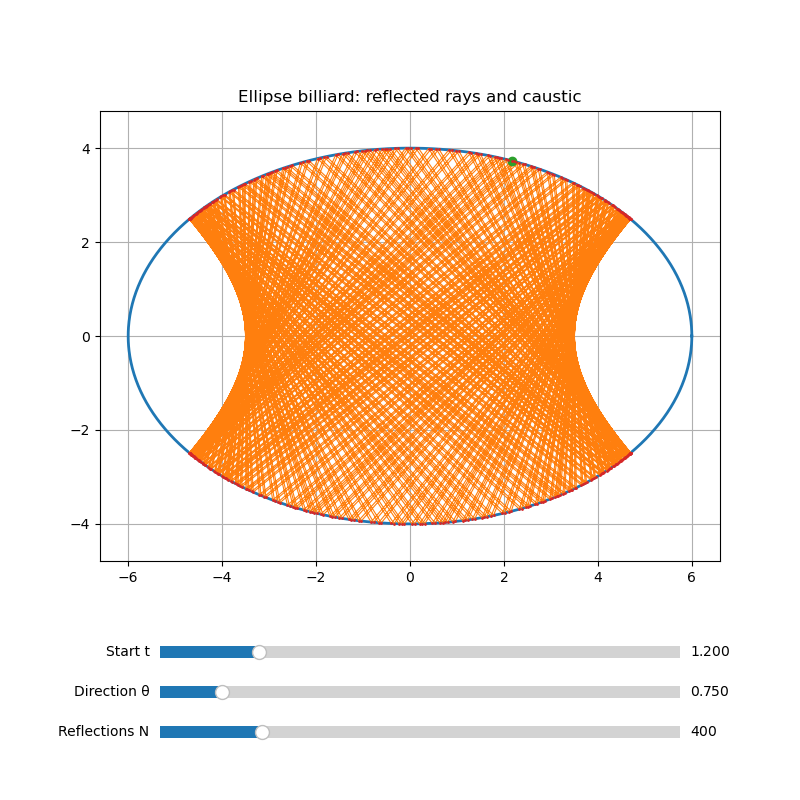

In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

# ============================================================
# Ellipse billiards / caustic visualizer
# ============================================================

A0 = 6.0          # ellipse semi-major axis
B0 = 4.0          # ellipse semi-minor axis
N0 = 400          # number of reflections
T0 = 1.2          # starting parameter on ellipse
THETA0 = 0.75     # initial ray direction angle


def ellipse_point(a, b, t):
    return np.array([a * np.cos(t), b * np.sin(t)], dtype=float)


def normal_to_ellipse(P, a, b):
    x, y = P
    n = np.array([x / a**2, y / b**2], dtype=float)
    return n / np.linalg.norm(n)


def reflect(v, n):
    return v - 2.0 * np.dot(v, n) * n


def next_intersection(P, v, a, b):
    """
    Finds the next intersection of ray P + s v with ellipse:
        x^2/a^2 + y^2/b^2 = 1

    P is assumed to be on the ellipse.
    One root is approximately zero, so we take the other forward root.
    """

    x, y = P
    vx, vy = v

    A = vx**2 / a**2 + vy**2 / b**2
    B = 2.0 * (x * vx / a**2 + y * vy / b**2)
    C = x**2 / a**2 + y**2 / b**2 - 1.0

    disc = B**2 - 4.0 * A * C

    if disc < 0 and disc > -1e-12:
        disc = 0.0

    if disc < 0:
        raise ValueError("No real intersection with ellipse.")

    sqrt_disc = np.sqrt(disc)

    r1 = (-B - sqrt_disc) / (2.0 * A)
    r2 = (-B + sqrt_disc) / (2.0 * A)

    roots = np.array([r1, r2], dtype=float)

    forward_roots = roots[roots > 1e-8]

    if len(forward_roots) == 0:
        # numerical fallback: choose the root furthest from zero
        s = roots[np.argmax(np.abs(roots))]
    else:
        s = np.min(forward_roots)

    return P + s * v


def billiard(a, b, t0, theta0, N):
    P = ellipse_point(a, b, t0)

    v = np.array([np.cos(theta0), np.sin(theta0)], dtype=float)
    v = v / np.linalg.norm(v)

    pts = [P.copy()]

    for _ in range(int(N)):
        P_next = next_intersection(P, v, a, b)

        n = normal_to_ellipse(P_next, a, b)

        v = reflect(v, n)
        v = v / np.linalg.norm(v)

        P = P_next

        pts.append(P.copy())

    return np.array(pts)


# ============================================================
# Plot setup
# ============================================================

fig, ax = plt.subplots(figsize=(8, 8))
plt.subplots_adjust(bottom=0.28)

t = np.linspace(0, 2 * np.pi, 1000)
ellipse_x = A0 * np.cos(t)
ellipse_y = B0 * np.sin(t)

boundary, = ax.plot(ellipse_x, ellipse_y, linewidth=2)

pts = billiard(A0, B0, T0, THETA0, N0)
path, = ax.plot(pts[:, 0], pts[:, 1], linewidth=0.8)

start_dot, = ax.plot([pts[0, 0]], [pts[0, 1]], marker="o")
impact_dots, = ax.plot(pts[:, 0], pts[:, 1], ".", markersize=2)

ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-A0 * 1.1, A0 * 1.1)
ax.set_ylim(-B0 * 1.2, B0 * 1.2)
ax.grid(True)
ax.set_title("Ellipse billiard: reflected rays and caustic")

# ============================================================
# Sliders
# ============================================================

ax_t0 = plt.axes([0.20, 0.17, 0.65, 0.03])
ax_theta = plt.axes([0.20, 0.12, 0.65, 0.03])
ax_N = plt.axes([0.20, 0.07, 0.65, 0.03])

s_t0 = Slider(ax_t0, "Start t", 0.0, 2 * np.pi, valinit=T0)
s_theta = Slider(ax_theta, "Direction θ", 0.0, 2 * np.pi, valinit=THETA0)
s_N = Slider(ax_N, "Reflections N", 10, 2000, valinit=N0, valstep=10)


def update(_):
    N = int(s_N.val)

    pts = billiard(
        A0,
        B0,
        s_t0.val,
        s_theta.val,
        N
    )

    path.set_data(pts[:, 0], pts[:, 1])
    start_dot.set_data([pts[0, 0]], [pts[0, 1]])
    impact_dots.set_data(pts[:, 0], pts[:, 1])

    fig.canvas.draw_idle()


s_t0.on_changed(update)
s_theta.on_changed(update)
s_N.on_changed(update)

plt.show()